# Đồ án: Nhận diện tiền Việt Nam và giải thích hình ảnh trên từng tờ tiền

## Thành viên nhóm

1. MSSV: 24521725  
   Họ và tên: Đoàn Nguyễn Minh Thư  

2. MSSV: 24520980  
   Họ và tên: Huỳnh Nguyễn Hoài Lộc  

3. MSSV: 24521871  
   Họ và tên: Trần Thanh Trúc  

## Kết nối GG Drive

In [2]:
from google.colab import drive
drive.mount ('/content/drive')

Mounted at /content/drive


## Kết nối dataset

In [3]:
DATASET_PATH = '/content/drive/MyDrive/UIT_YEAR2/CS231/DoAn/DATASET'

# HOG + Color + SVM

In [4]:
# Import thư viện
import os
import cv2
import numpy as np
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import LinearSVC
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [5]:
# Resize ảnh về (128, 64)
IMG_SIZE = (128, 64)

# Trích xuất đặc trưng HOG và Color
def extract_features(img_path):
    # 1. Đọc ảnh và resize
    image = cv2.imread(img_path)
    if image is None: return None
    image = cv2.resize(image, IMG_SIZE)

    # 2. Trích xuất đặc trưng HOG (Chuyển sang ảnh xám trước khi tính HOG)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    hog_features = hog(gray, orientations=9, pixels_per_cell=(8, 8),
                       cells_per_block=(2, 2), block_norm='L2-Hys', visualize=False)

    # 3. Trích xuất đặc trưng Color Histogram (Dùng hệ màu HSV)
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    # Tính histogram cho 3 kênh H, S, V với số bins tương ứng (chỉnh số bins để giảm chiều vector)
    hist_h = cv2.calcHist([hsv], [0], None, [32], [0, 180]).flatten()
    hist_s = cv2.calcHist([hsv], [1], None, [32], [0, 256]).flatten()
    hist_v = cv2.calcHist([hsv], [2], None, [32], [0, 256]).flatten()

    # Chuẩn hóa histogram để không bị ảnh hưởng bởi độ sáng tổng thể
    color_features = np.concatenate([hist_h, hist_s, hist_v])
    cv2.normalize(color_features, color_features)

    # 4. Gộp HOG và Color thành 1 vector duy nhất
    combined_features = np.concatenate([hog_features, color_features])

    return combined_features

In [6]:
def load_data_and_extract_features(dataset_dir):
    X = [] # Chứa các vector đặc trưng
    y = [] # Chứa nhãn (label)

    denominations = [d for d in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, d))]

    for denomination in denominations:
        deno_path = os.path.join(dataset_dir, denomination)
        sides = [s for s in os.listdir(deno_path) if os.path.isdir(os.path.join(deno_path, s))]

        for side in sides:
            side_path = os.path.join(deno_path, side)
            label = f"{denomination}_{side}"

            for file in os.listdir(side_path):
                if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    img_path = os.path.join(side_path, file)
                    features = extract_features(img_path)

                    if features is not None:
                        X.append(features)
                        y.append(label)

    return np.array(X), np.array(y)

In [7]:
TRAIN_DIR = os.path.join(DATASET_PATH, 'train')
VAL_DIR = os.path.join(DATASET_PATH, 'val')
TEST_DIR = os.path.join(DATASET_PATH, 'test')   # 👈 thêm test

print("1. Đang trích xuất đặc trưng tập TRAIN (Có thể mất vài phút)...")
X_train, y_train = load_data_and_extract_features(TRAIN_DIR)

print("2. Đang trích xuất đặc trưng tập VAL...")
X_val, y_val = load_data_and_extract_features(VAL_DIR)

print("3. Đang trích xuất đặc trưng tập TEST...")
X_test, y_test = load_data_and_extract_features(TEST_DIR)   # 👈 thêm test

print("4. Chuẩn hóa dữ liệu...")
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)   # 👈 nhớ transform test

print("5. Bắt đầu huấn luyện mô hình SVM...")
svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    class_weight='balanced',
    random_state=42
)

svm_model.fit(X_train, y_train)

print("6. Đánh giá mô hình trên tập VAL...")
y_val_pred = svm_model.predict(X_val)

val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"\n=> VAL ACCURACY: {val_accuracy * 100:.2f}%")
print(classification_report(y_val, y_val_pred))

print("7. Đánh giá mô hình trên tập TEST...")
y_test_pred = svm_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"\n=> TEST ACCURACY: {test_accuracy * 100:.2f}%")

print("\nBÁO CÁO CHI TIẾT TEST:")
print(classification_report(y_test, y_test_pred))

# Lưu model
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(svm_model, 'svm_money_model.pkl')
print("Đã lưu model tại 'svm_money_model.pkl'")

1. Đang trích xuất đặc trưng tập TRAIN (Có thể mất vài phút)...
2. Đang trích xuất đặc trưng tập VAL...
3. Đang trích xuất đặc trưng tập TEST...
4. Chuẩn hóa dữ liệu...
5. Bắt đầu huấn luyện mô hình SVM...
6. Đánh giá mô hình trên tập VAL...

=> VAL ACCURACY: 65.45%
              precision    recall  f1-score   support

  000200_sau       0.14      0.07      0.09        15
000200_truoc       0.24      0.40      0.30        15
  000500_sau       0.58      0.73      0.65        15
000500_truoc       0.89      0.53      0.67        15
  001000_sau       0.33      0.20      0.25        15
001000_truoc       0.42      0.67      0.51        15
  002000_sau       0.67      0.80      0.73        15
002000_truoc       0.55      0.80      0.65        15
  005000_sau       0.71      0.67      0.69        15
005000_truoc       1.00      0.53      0.70        15
  010000_sau       0.93      0.87      0.90        15
010000_truoc       0.93      0.93      0.93        15
  020000_sau       1.00      1

8. Vẽ Confusion Matrix cho tập TEST...


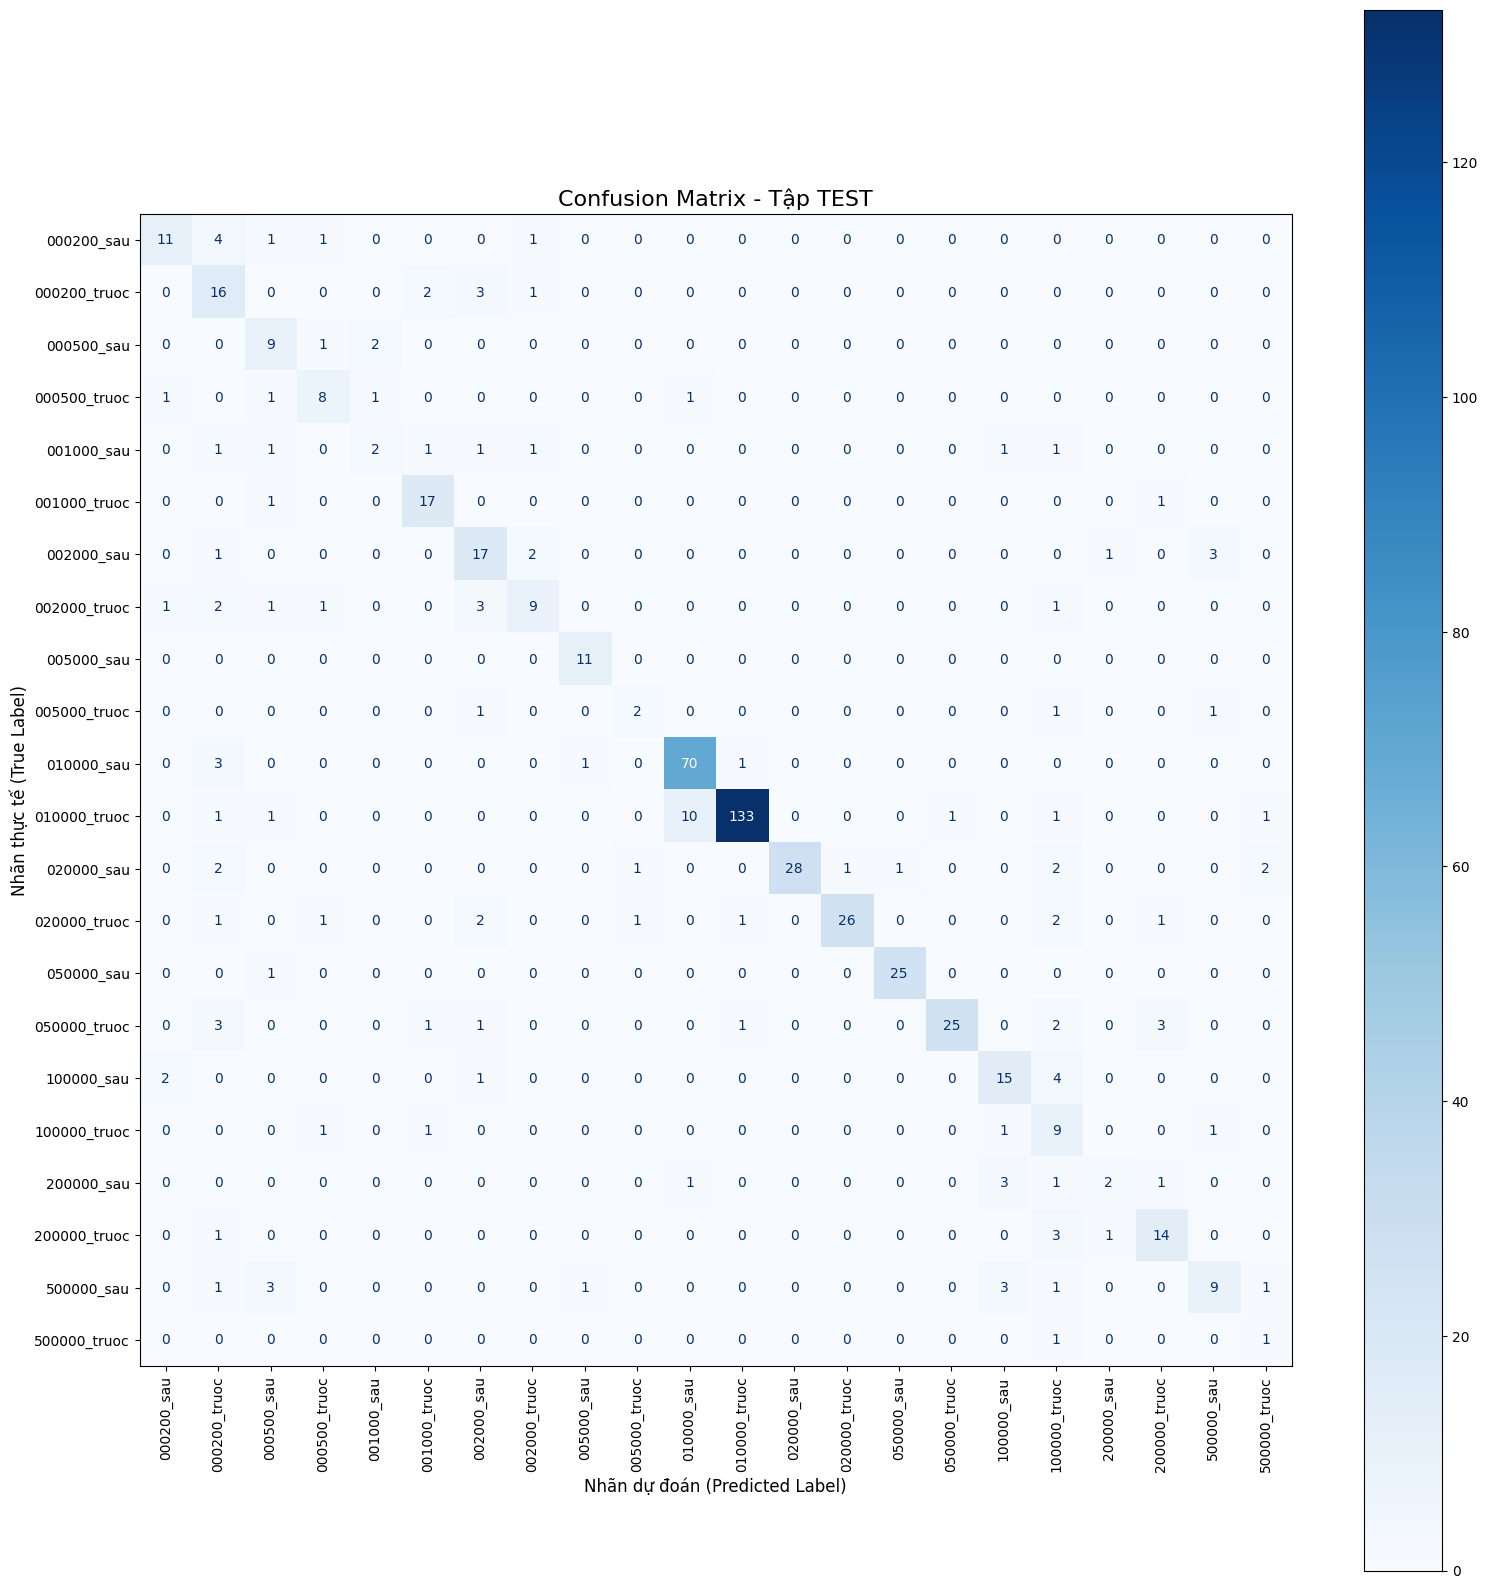

In [8]:
print("8. Vẽ Confusion Matrix cho tập TEST...")

# Lấy danh sách các nhãn (labels) thực tế từ mô hình
labels = svm_model.classes_

# Tính toán confusion matrix
cm = confusion_matrix(y_test, y_test_pred, labels=labels)

# Khởi tạo figure với kích thước lớn vì dataset của bạn có khá nhiều class (hơn 30 class)
fig, ax = plt.subplots(figsize=(16, 16))

# Cấu hình và vẽ Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

# xticks_rotation='vertical' giúp chữ ở trục X dựng dọc lên, không bị đè vào nhau
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')

plt.title('Confusion Matrix - Tập TEST', fontsize=16)
plt.xlabel('Nhãn dự đoán (Predicted Label)', fontsize=12)
plt.ylabel('Nhãn thực tế (True Label)', fontsize=12)

# Tối ưu khoảng cách hiển thị và show hình
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files

files.download('svm_money_model.pkl')
files.download('scaler.pkl')
